In [2]:
!pip install pandas numpy matplotlib scipy scikit-learn seaborn yfinance arch --quiet
print("Libraries installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 14.2 MB/s eta 0:00:00
Libraries installed!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import yfinance as yf
from scipy import stats
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf
from arch import arch_model
from datetime import datetime

warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams['figure.facecolor'] = '#0A1628'
plt.rcParams['axes.facecolor']   = '#0A1628'
plt.rcParams['axes.edgecolor']   = '#1E3A5F'
plt.rcParams['text.color']       = 'white'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'
plt.rcParams['grid.color']       = '#1E3A5F'
plt.rcParams['grid.alpha']       = 0.4
plt.rcParams['font.family']      = 'monospace'

GOLD   = '#C8972B'
BLUE   = '#4A90D9'
GREEN  = '#2ECC71'
RED    = '#E74C3C'
WHITE  = '#FFFFFF'
GREY   = '#8899AA'
PURPLE = '#9B59B6'

START_DATE   = "2015-01-01"
END_DATE     = datetime.today().strftime("%Y-%m-%d")
PORTFOLIO_AUD = 100_000_000  # $100M AUD portfolio
CONFIDENCE    = [0.95, 0.99, 0.999]
HOLDING_PERIOD = 10  # APRA 10-day holding period

# ASX multi-asset portfolio
PORTFOLIO = {
    'STW.AX'  : ('ASX 200 Equities',  0.35),
    'VGS.AX'  : ('Global Equities',   0.20),
    'IAF.AX'  : ('AGS Bonds',         0.20),
    'VAP.AX'  : ('ASX REITs',         0.10),
    'GLD'     : ('Gold',              0.10),
    'AUDUSD=X': ('AUD/USD',           0.05),
}

print("=" * 60)
print("  INSTITUTIONAL MARKET RISK DASHBOARD")
print("  APRA APS 116 Aligned | VaR | CVaR | Stress Testing")
print("=" * 60)
print(f"  Portfolio AUM  : AUD {PORTFOLIO_AUD/1e6:.0f}M")
print(f"  Holding period : {HOLDING_PERIOD} days (APRA standard)")
print(f"  Confidence     : {[f'{c*100:.1f}%' for c in CONFIDENCE]}")
print("=" * 60)

  INSTITUTIONAL MARKET RISK DASHBOARD
  APRA APS 116 Aligned | VaR | CVaR | Stress Testing
  Portfolio AUM  : AUD 100M
  Holding period : 10 days (APRA standard)
  Confidence     : ['95.0%', '99.0%', '99.9%']


In [4]:
print("\nDownloading portfolio data...")

tickers = list(PORTFOLIO.keys())
weights = np.array([v[1] for v in PORTFOLIO.values()])
names   = [v[0] for v in PORTFOLIO.values()]

raw    = yf.download(tickers, start=START_DATE, end=END_DATE,
                     auto_adjust=True, progress=True)
prices = raw['Close'].copy()

if isinstance(prices.columns, pd.MultiIndex):
    prices.columns = prices.columns.get_level_values(0)

prices = prices.fillna(method='ffill', limit=5).dropna()
available = [t for t in tickers if t in prices.columns]
prices    = prices[available]

# Recompute weights for available assets
wt_map  = {t: PORTFOLIO[t][1] for t in available}
weights = np.array([wt_map[t] for t in available])
weights = weights / weights.sum()
names   = [PORTFOLIO[t][0] for t in available]

# Daily returns
returns = prices.pct_change().dropna()

# Portfolio returns
port_rets = returns @ weights

print(f"\nLoaded {len(available)} assets, {len(returns)} trading days")
print(f"Date range: {returns.index[0].date()} to {returns.index[-1].date()}")
print(f"\nPortfolio composition:")
for t, n, w in zip(available, names, weights):
    print(f"  {n:<22}: {w*100:.1f}%")

[*********************100%***********************]  6 of 6 completed


Loaded 6 assets, 2997 trading days
Date range: 2015-01-05 to 2026-07-04

Portfolio composition:
  ASX 200 Equities      : 35.0%
  Global Equities       : 20.0%
  AGS Bonds             : 20.0%
  ASX REITs             : 10.0%
  Gold                  : 10.0%
  AUD/USD               : 5.0%


In [5]:
print("\nComputing VaR and CVaR using 3 methods...")

# ── Method 1: Historical Simulation ──────────────────────────────────────────
def historical_var_cvar(returns, confidence, holding_period=1):
    scaled = returns * np.sqrt(holding_period)
    var    = -np.percentile(scaled, (1 - confidence) * 100)
    cvar   = -scaled[scaled <= -var].mean()
    return var, cvar

# ── Method 2: Parametric (Normal) ────────────────────────────────────────────
def parametric_var_cvar(returns, confidence, holding_period=1):
    mu     = returns.mean() * holding_period
    sigma  = returns.std()  * np.sqrt(holding_period)
    z      = stats.norm.ppf(confidence)
    var    = -(mu - z * sigma)
    # CVaR = -mu + sigma * phi(z) / (1 - confidence)
    cvar   = -(mu - sigma * stats.norm.pdf(z) / (1 - confidence))
    return var, cvar

# ── Method 3: GARCH-filtered Historical ──────────────────────────────────────
def garch_var_cvar(returns, confidence, holding_period=1):
    try:
        am     = arch_model(returns * 100, vol='Garch', p=1, q=1, dist='normal')
        res    = am.fit(disp='off')
        fc     = res.forecast(horizon=holding_period)
        vol_fc = np.sqrt(fc.variance.values[-1, -1]) / 100
        std_resid = res.std_resid.dropna()
        scaled_resid = std_resid * vol_fc
        var  = -np.percentile(scaled_resid, (1 - confidence) * 100)
        cvar = -scaled_resid[scaled_resid <= -var].mean()
        return var, cvar
    except Exception:
        return parametric_var_cvar(returns, confidence, holding_period)

# Compute all VaR/CVaR
results_var = {}
for conf in CONFIDENCE:
    h_var,  h_cvar  = historical_var_cvar(port_rets, conf, HOLDING_PERIOD)
    p_var,  p_cvar  = parametric_var_cvar(port_rets, conf, HOLDING_PERIOD)
    g_var,  g_cvar  = garch_var_cvar(port_rets, conf, HOLDING_PERIOD)

    results_var[conf] = {
        'hist_var' : h_var,  'hist_cvar' : h_cvar,
        'para_var' : p_var,  'para_cvar' : p_cvar,
        'garch_var': g_var,  'garch_cvar': g_cvar,
    }

print(f"\n  {HOLDING_PERIOD}-Day VaR & CVaR (as % of portfolio)")
print(f"  {'Confidence':<12} {'Method':<12} {'VaR':>8} {'CVaR':>8} "
      f"{'VaR ($M)':>10} {'CVaR ($M)':>10}")
print(f"  {'-'*65}")

for conf, r in results_var.items():
    for method, var_key, cvar_key in [
        ('Historical', 'hist_var',  'hist_cvar'),
        ('Parametric', 'para_var',  'para_cvar'),
        ('GARCH',      'garch_var', 'garch_cvar'),
    ]:
        var  = r[var_key]
        cvar = r[cvar_key]
        print(f"  {conf*100:.1f}%       {method:<12} {var*100:>7.2f}% "
              f"{cvar*100:>7.2f}% "
              f"{var*PORTFOLIO_AUD/1e6:>9.2f}M "
              f"{cvar*PORTFOLIO_AUD/1e6:>9.2f}M")
    print()


Computing VaR and CVaR using 3 methods...

  10-Day VaR & CVaR (as % of portfolio)
  Confidence   Method            VaR     CVaR   VaR ($M)  CVaR ($M)
  -----------------------------------------------------------------
  95.0%       Historical      2.65%    4.21%      2.65M      4.21M
  95.0%       Parametric      2.54%    3.27%      2.54M      3.27M
  95.0%       GARCH           0.75%    1.08%      0.75M      1.08M

  99.0%       Historical      4.90%    7.29%      4.90M      7.29M
  99.0%       Parametric      3.72%    4.31%      3.72M      4.31M
  99.0%       GARCH           1.30%    1.52%      1.30M      1.52M

  99.9%       Historical     11.71%   12.93%     11.71M     12.93M
  99.9%       Parametric      5.05%    5.53%      5.05M      5.53M
  99.9%       GARCH           1.78%    1.87%      1.78M      1.87M



In [6]:
print("\nComputing Component VaR and risk attribution...")

# Covariance matrix (Ledoit-Wolf shrinkage)
lw      = LedoitWolf()
lw.fit(returns[available].values)
cov_ann = lw.covariance_ * 252
cov_daily = lw.covariance_

# Portfolio volatility
port_vol_daily = np.sqrt(weights @ cov_daily @ weights)
port_vol_ann   = port_vol_daily * np.sqrt(252)

# Component VaR (99% confidence, 10-day)
z_99      = stats.norm.ppf(0.99)
mrc       = cov_daily @ weights / port_vol_daily  # Marginal risk contribution
cvar_comp = weights * mrc * z_99 * np.sqrt(HOLDING_PERIOD)  # Component VaR
pvar_total = port_vol_daily * z_99 * np.sqrt(HOLDING_PERIOD)  # Total portfolio VaR

# Risk contribution %
rc_pct = cvar_comp / pvar_total * 100

print(f"\n  Portfolio Annual Volatility: {port_vol_ann*100:.2f}%")
print(f"  Portfolio 10-day 99% VaR   : {pvar_total*100:.2f}% "
      f"(AUD {pvar_total*PORTFOLIO_AUD/1e6:.2f}M)")

print(f"\n  COMPONENT VaR & RISK ATTRIBUTION")
print(f"  {'Asset':<22} {'Weight':>8} {'Comp VaR':>10} {'Risk Contrib':>13} {'Marginal RC':>12}")
print(f"  {'-'*68}")
for n, w, cv, rc, mr in zip(names, weights, cvar_comp, rc_pct, mrc):
    print(f"  {n:<22} {w*100:>7.1f}% {cv*100:>9.3f}% {rc:>12.1f}% "
          f"{mr*100:>11.3f}%")

# Correlation matrix
corr_df = pd.DataFrame(
    np.corrcoef(returns[available].T),
    index=names, columns=names
)


Computing Component VaR and risk attribution...

  Portfolio Annual Volatility: 8.70%
  Portfolio 10-day 99% VaR   : 4.03% (AUD 4.03M)

  COMPONENT VaR & RISK ATTRIBUTION
  Asset                    Weight   Comp VaR  Risk Contrib  Marginal RC
  --------------------------------------------------------------------
  ASX 200 Equities          35.0%     2.159%         53.5%       0.839%
  Global Equities           20.0%     0.883%         21.9%       0.600%
  AGS Bonds                 20.0%     0.099%          2.5%       0.067%
  ASX REITs                 10.0%     0.693%         17.2%       0.943%
  Gold                      10.0%     0.145%          3.6%       0.198%
  AUD/USD                    5.0%     0.053%          1.3%       0.145%


In [7]:
print("\nApplying APRA APS 116 stress scenarios...")

# APRA-style stress scenarios for Australian institutions
STRESS_SCENARIOS = {
    'GFC 2008-09': {
        'ASX 200 Equities' : -0.52,
        'Global Equities'  : -0.48,
        'AGS Bonds'        : +0.08,
        'ASX REITs'        : -0.65,
        'Gold'             : +0.05,
        'AUD/USD'          : -0.28,
    },
    'COVID Crash (Mar 2020)': {
        'ASX 200 Equities' : -0.37,
        'Global Equities'  : -0.34,
        'AGS Bonds'        : +0.05,
        'ASX REITs'        : -0.42,
        'Gold'             : -0.03,
        'AUD/USD'          : -0.18,
    },
    'RBA +300bps (APRA)': {
        'ASX 200 Equities' : -0.25,
        'Global Equities'  : -0.20,
        'AGS Bonds'        : -0.18,
        'ASX REITs'        : -0.30,
        'Gold'             : +0.08,
        'AUD/USD'          : +0.05,
    },
    'AUD -30% (Trade War)': {
        'ASX 200 Equities' : -0.15,
        'Global Equities'  : +0.10,
        'AGS Bonds'        : +0.03,
        'ASX REITs'        : -0.10,
        'Gold'             : +0.15,
        'AUD/USD'          : -0.30,
    },
    'China Hard Landing': {
        'ASX 200 Equities' : -0.35,
        'Global Equities'  : -0.25,
        'AGS Bonds'        : +0.06,
        'ASX REITs'        : -0.20,
        'Gold'             : +0.10,
        'AUD/USD'          : -0.22,
    },
    'Severe Adverse (APRA)': {
        'ASX 200 Equities' : -0.60,
        'Global Equities'  : -0.55,
        'AGS Bonds'        : -0.05,
        'ASX REITs'        : -0.70,
        'Gold'             : +0.12,
        'AUD/USD'          : -0.35,
    },
}

scenario_results = {}
print(f"\n  {'Scenario':<28} {'P&L ($M)':>10} {'P&L (%)':>10} {'Worst Asset'}")
print(f"  {'-'*72}")

for scenario, shocks in STRESS_SCENARIOS.items():
    pnl = 0
    asset_pnls = {}
    for t, n, w in zip(available, names, weights):
        shock      = shocks.get(n, 0)
        asset_pnl  = shock * w * PORTFOLIO_AUD
        pnl       += asset_pnl
        asset_pnls[n] = asset_pnl

    pnl_pct      = pnl / PORTFOLIO_AUD * 100
    worst_asset  = min(asset_pnls, key=asset_pnls.get)
    worst_pnl    = asset_pnls[worst_asset]

    scenario_results[scenario] = {
        'pnl'        : pnl,
        'pnl_pct'    : pnl_pct,
        'asset_pnls' : asset_pnls,
    }
    print(f"  {scenario:<28} {pnl/1e6:>+9.1f}M {pnl_pct:>9.1f}%  "
          f"{worst_asset} ({worst_pnl/1e6:>+.1f}M)")


Applying APRA APS 116 stress scenarios...

  Scenario                       P&L ($M)    P&L (%) Worst Asset
  ------------------------------------------------------------------------
  GFC 2008-09                      -33.6M     -33.6%  ASX 200 Equities (-18.2M)
  COVID Crash (Mar 2020)           -24.1M     -24.1%  ASX 200 Equities (-12.9M)
  RBA +300bps (APRA)               -18.3M     -18.3%  ASX 200 Equities (-8.8M)
  AUD -30% (Trade War)              -3.6M      -3.6%  ASX 200 Equities (-5.2M)
  China Hard Landing               -18.1M     -18.1%  ASX 200 Equities (-12.2M)
  Severe Adverse (APRA)            -40.5M     -40.6%  ASX 200 Equities (-21.0M)


In [8]:
print("\nBacktesting VaR model (Kupiec Proportion of Failures test)...")

def kupiec_test(returns, var_series, confidence):
    """
    Kupiec (1995) POF test for VaR model validity.
    H0: VaR model is correctly specified
    """
    violations = (returns < -var_series).sum()
    n          = len(returns)
    p_hat      = violations / n
    p_expected = 1 - confidence

    if p_hat == 0 or p_hat == 1:
        return violations, n, p_hat, np.nan, np.nan, 'INCONCLUSIVE'

    lr_pof = -2 * (
        n * np.log(1 - p_expected) + violations * np.log(p_expected) -
        n * np.log(1 - p_hat) - violations * np.log(p_hat)
    )
    p_value = 1 - stats.chi2.cdf(lr_pof, df=1)
    result  = 'PASS' if p_value > 0.05 else 'FAIL'

    return violations, n, p_hat, lr_pof, p_value, result

# 1-day VaR for backtesting
print(f"\n  {'Confidence':<12} {'Method':<12} {'Violations':>11} "
      f"{'Exp Viol':>10} {'Act Rate':>10} {'LR Stat':>9} {'P-value':>9} {'Result':>8}")
print(f"  {'-'*85}")

backtest_results = {}
for conf in [0.95, 0.99]:
    h_var_1d, _ = historical_var_cvar(port_rets, conf, 1)
    p_var_1d, _ = parametric_var_cvar(port_rets, conf, 1)

    for method, var_val in [('Historical', h_var_1d), ('Parametric', p_var_1d)]:
        var_series = pd.Series(var_val, index=port_rets.index)
        viol, n, p_hat, lr, pv, result = kupiec_test(port_rets, var_series, conf)
        exp_viol   = int(n * (1 - conf))
        color_tag  = 'PASS' if result == 'PASS' else 'FAIL'
        print(f"  {conf*100:.1f}%       {method:<12} {viol:>11} "
              f"{exp_viol:>10} {p_hat*100:>9.2f}% "
              f"{lr:>9.3f} {pv:>9.4f} {color_tag:>8}")
        backtest_results[f'{conf}_{method}'] = {
            'violations': viol, 'n': n, 'result': result
        }


Backtesting VaR model (Kupiec Proportion of Failures test)...

  Confidence   Method        Violations   Exp Viol   Act Rate   LR Stat   P-value   Result
  -------------------------------------------------------------------------------------
  95.0%       Historical           150        149      5.01%    -0.016    1.0000     PASS
  95.0%       Parametric           133        149      4.44%     3.639    0.0564     PASS
  99.0%       Historical            30         29      1.00%    -0.001    1.0000     PASS
  99.0%       Parametric            55         29      1.84%    16.005    0.0001     FAIL


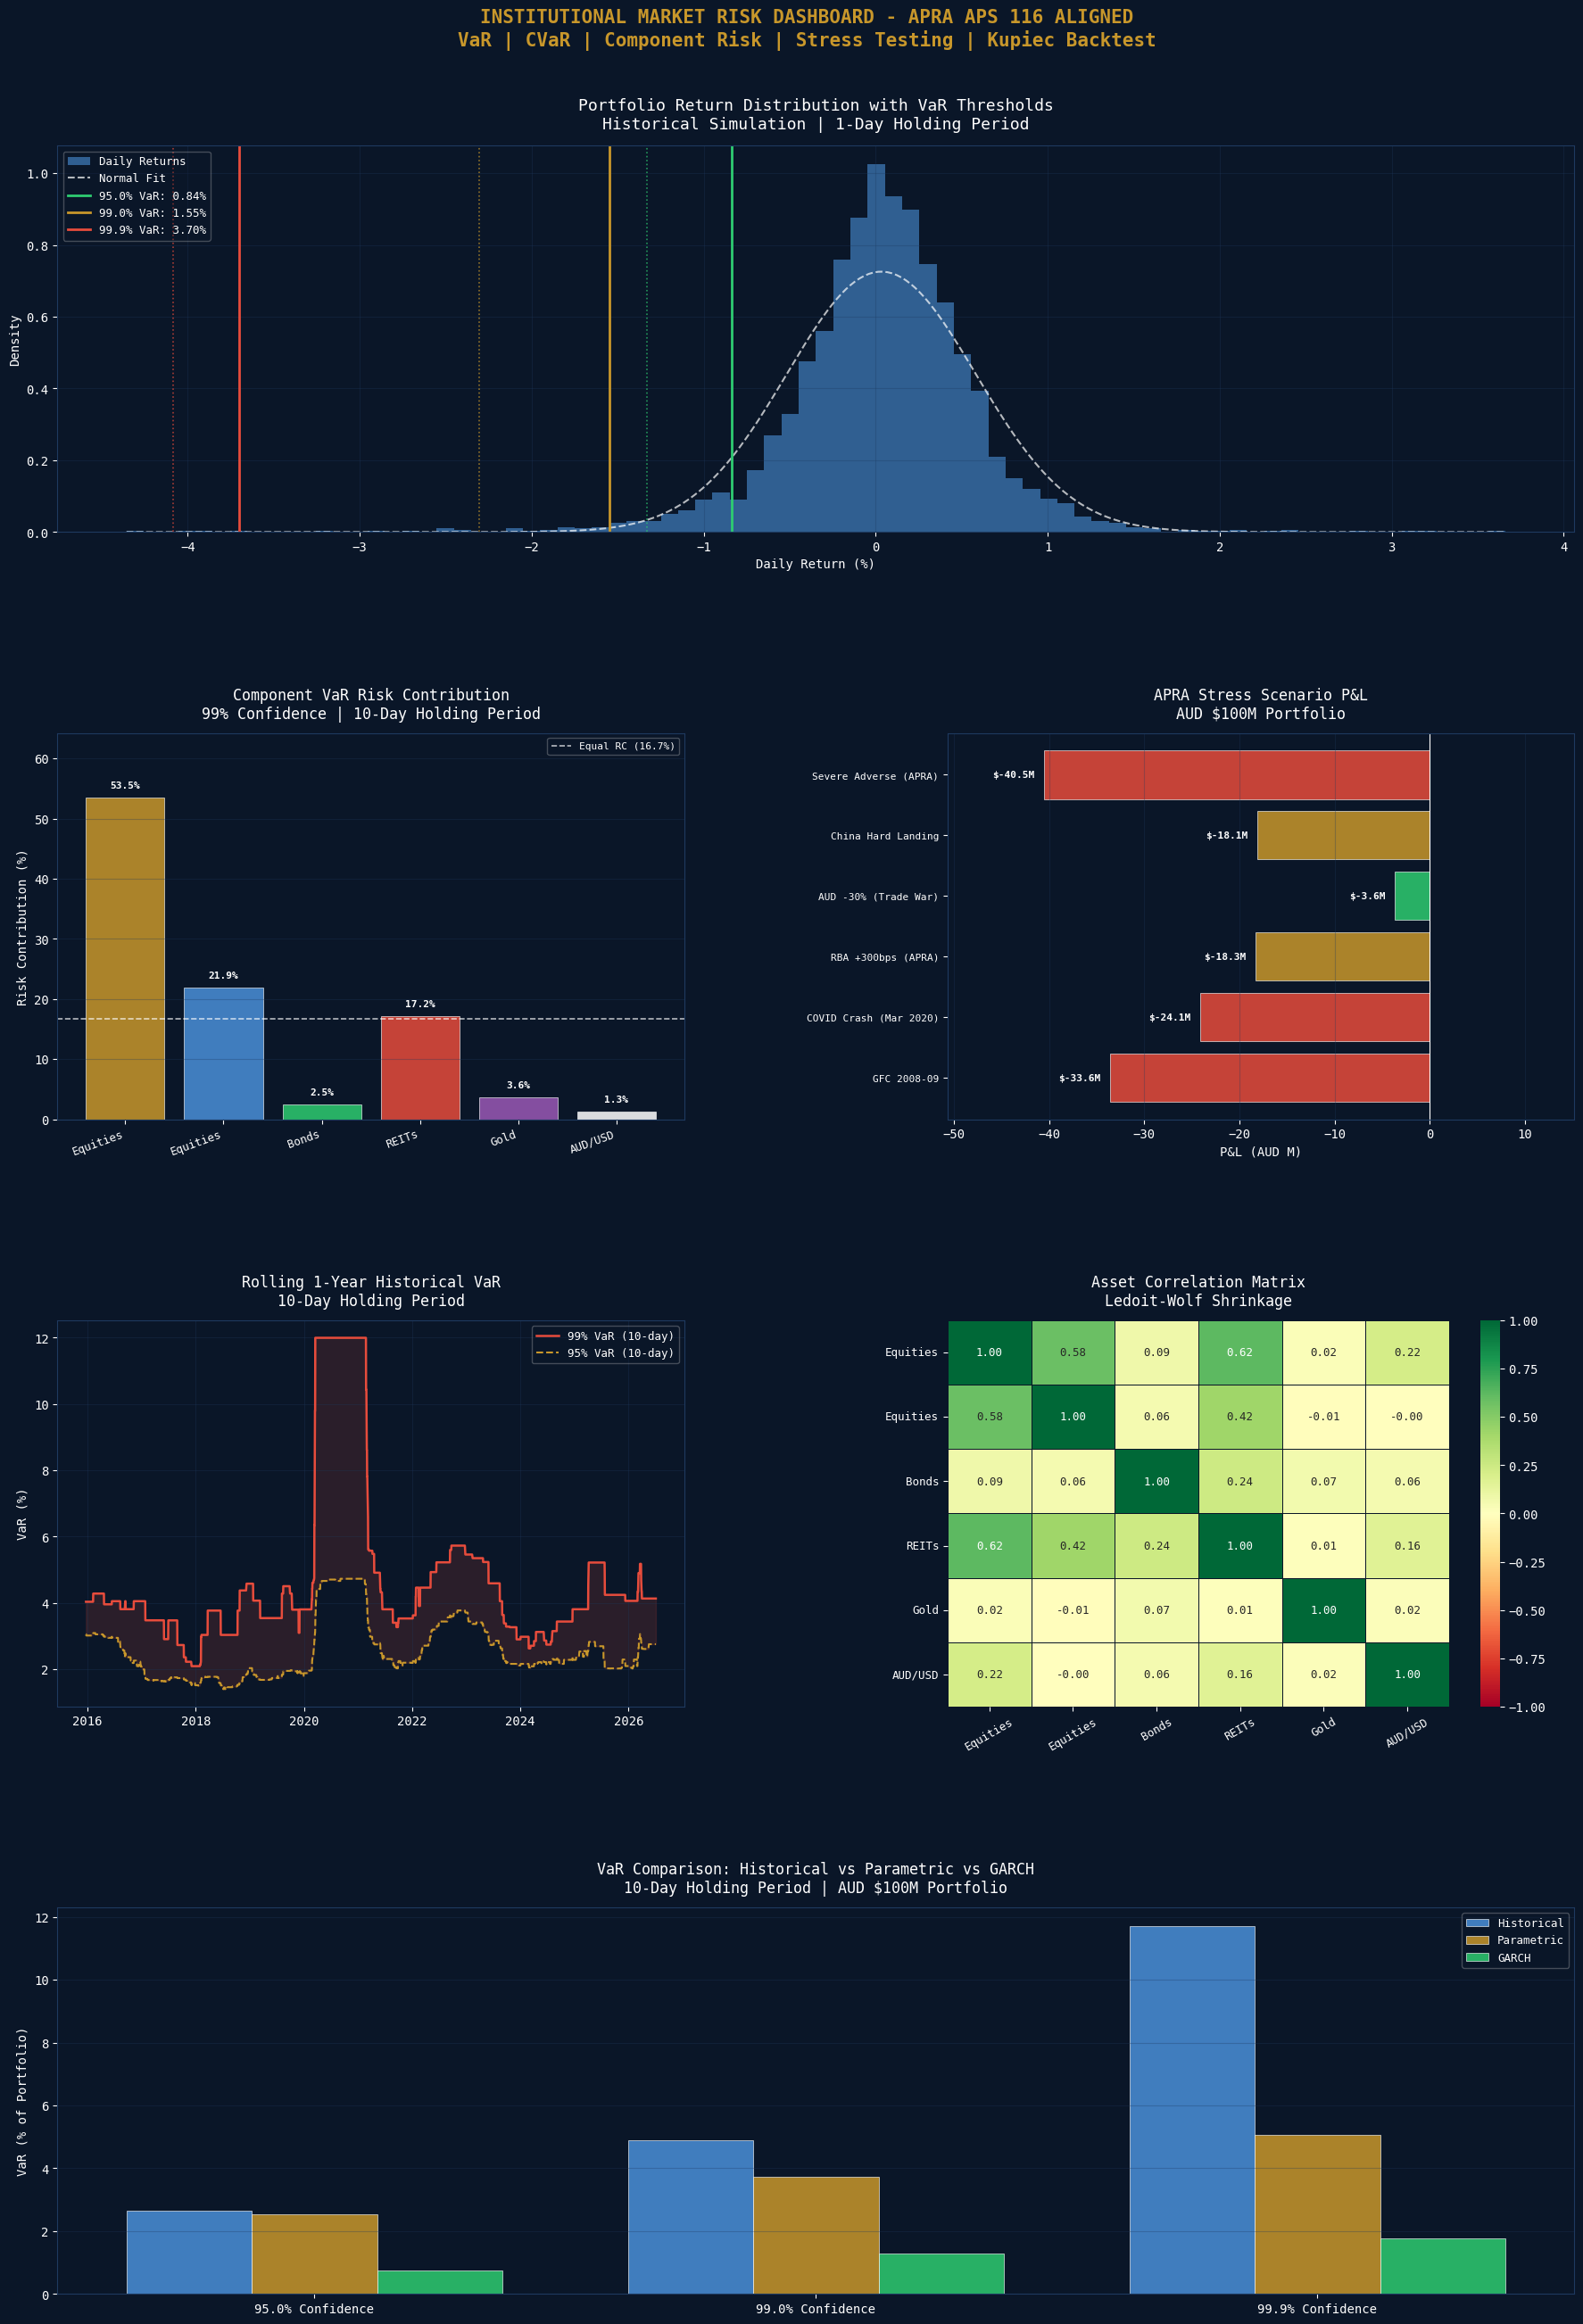

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Chart saved and downloaded!


In [9]:
from google.colab import files

fig = plt.figure(figsize=(20, 28))
fig.patch.set_facecolor('#0A1628')
gs  = gridspec.GridSpec(
    4, 2, figure=fig,
    hspace=0.52, wspace=0.42,
    left=0.08, right=0.93,
    top=0.91, bottom=0.05
)

# ── Chart 1: Portfolio Return Distribution with VaR lines ─────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.hist(port_rets * 100, bins=80, color=BLUE, alpha=0.6,
         edgecolor='none', density=True, label='Daily Returns')

# Fit normal
mu_fit, sig_fit = stats.norm.fit(port_rets)
x_fit = np.linspace(port_rets.min()*100, port_rets.max()*100, 300)
ax1.plot(x_fit, stats.norm.pdf(x_fit/100, mu_fit, sig_fit)/100,
         color=WHITE, lw=1.5, linestyle='--', label='Normal Fit', alpha=0.7)

# VaR lines
colors_conf = [GREEN, GOLD, RED]
for conf, c in zip(CONFIDENCE, colors_conf):
    var_1d, cvar_1d = historical_var_cvar(port_rets, conf, 1)
    ax1.axvline(x=-var_1d*100, color=c, lw=2.0,
                label=f'{conf*100:.1f}% VaR: {var_1d*100:.2f}%')
    ax1.axvline(x=-cvar_1d*100, color=c, lw=1.2, linestyle=':',
                alpha=0.7)

ax1.set_title('Portfolio Return Distribution with VaR Thresholds\n'
              'Historical Simulation | 1-Day Holding Period',
              fontsize=13, color=WHITE, pad=14)
ax1.set_xlabel('Daily Return (%)', color=WHITE)
ax1.set_ylabel('Density', color=WHITE)
ax1.legend(fontsize=9, framealpha=0.3, loc='upper left')
ax1.set_facecolor('#0A1628')
ax1.grid(True, alpha=0.3)

# ── Chart 2: Component VaR by Asset ──────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
colors_assets = [GOLD, BLUE, GREEN, RED, PURPLE, WHITE]
bars2 = ax2.bar(range(len(names)), rc_pct,
                color=colors_assets[:len(names)],
                alpha=0.85, edgecolor='white', lw=0.5)
ax2.axhline(y=100/len(names), color=WHITE, lw=1.2,
            linestyle='--', alpha=0.7,
            label=f'Equal RC ({100/len(names):.1f}%)')
ax2.set_xticks(range(len(names)))
ax2.set_xticklabels([n.split()[-1] for n in names],
                     rotation=20, ha='right', fontsize=9)
ax2.set_title('Component VaR Risk Contribution\n99% Confidence | 10-Day Holding Period',
              fontsize=12, color=WHITE, pad=12)
ax2.set_ylabel('Risk Contribution (%)', color=WHITE)
ax2.legend(fontsize=8, framealpha=0.3)
ax2.set_facecolor('#0A1628')
ax2.grid(True, alpha=0.3, axis='y')
x_max2 = max(rc_pct) * 1.20
ax2.set_ylim(0, x_max2)
for bar, val in zip(bars2, rc_pct):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + x_max2 * 0.02,
             f'{val:.1f}%', ha='center', va='bottom',
             color=WHITE, fontsize=8, fontweight='bold')

# ── Chart 3: Stress Scenario P&L ─────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
scenario_names_s = list(scenario_results.keys())
scenario_pnls    = [scenario_results[s]['pnl']/1e6 for s in scenario_names_s]
bar_colors_s     = [RED if p < -20 else GOLD if p < -10 else GREEN
                    for p in scenario_pnls]
bars3 = ax3.barh(range(len(scenario_names_s)), scenario_pnls,
                 color=bar_colors_s, alpha=0.85,
                 edgecolor='white', lw=0.5)
ax3.axvline(x=0, color=WHITE, lw=0.8)
ax3.set_yticks(range(len(scenario_names_s)))
ax3.set_yticklabels(scenario_names_s, fontsize=8)
ax3.set_title('APRA Stress Scenario P&L\nAUD $100M Portfolio',
              fontsize=12, color=WHITE, pad=12)
ax3.set_xlabel('P&L (AUD M)', color=WHITE)
ax3.set_facecolor('#0A1628')
ax3.grid(True, alpha=0.3, axis='x')
x_min3 = min(scenario_pnls) * 1.25
ax3.set_xlim(x_min3, abs(x_min3) * 0.3)
for bar, val in zip(bars3, scenario_pnls):
    ax3.text(val - abs(x_min3) * 0.02 if val < 0 else val + abs(x_min3) * 0.02,
             bar.get_y() + bar.get_height()/2,
             f'${val:>+.1f}M', va='center',
             ha='right' if val < 0 else 'left',
             color=WHITE, fontsize=8, fontweight='bold')

# ── Chart 4: Rolling 252-day VaR ─────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
rolling_var_95 = port_rets.rolling(252).quantile(0.05).abs() * np.sqrt(HOLDING_PERIOD) * 100
rolling_var_99 = port_rets.rolling(252).quantile(0.01).abs() * np.sqrt(HOLDING_PERIOD) * 100

ax4.plot(rolling_var_99.index, rolling_var_99.values, color=RED,
         lw=1.8, label='99% VaR (10-day)')
ax4.plot(rolling_var_95.index, rolling_var_95.values, color=GOLD,
         lw=1.5, linestyle='--', label='95% VaR (10-day)')
ax4.fill_between(rolling_var_99.index, rolling_var_95.values,
                  rolling_var_99.values, alpha=0.15, color=RED)
ax4.set_title('Rolling 1-Year Historical VaR\n10-Day Holding Period',
              fontsize=12, color=WHITE, pad=12)
ax4.set_ylabel('VaR (%)', color=WHITE)
ax4.legend(fontsize=9, framealpha=0.3)
ax4.set_facecolor('#0A1628')
ax4.grid(True, alpha=0.3)

# ── Chart 5: Correlation Heatmap ─────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
short_names = [n.split()[-1] for n in names]
corr_short  = pd.DataFrame(corr_df.values,
                             index=short_names,
                             columns=short_names)
sns.heatmap(corr_short, ax=ax5, cmap='RdYlGn', center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f',
            linewidths=0.5, linecolor='#0A1628',
            annot_kws={'size': 9})
ax5.set_title('Asset Correlation Matrix\nLedoit-Wolf Shrinkage',
              fontsize=12, color=WHITE, pad=12)
ax5.set_facecolor('#0A1628')
ax5.tick_params(axis='x', rotation=30, labelsize=9)
ax5.tick_params(axis='y', rotation=0,  labelsize=9)

# ── Chart 6: VaR Comparison (3 Methods) ──────────────────────────────────────
ax6 = fig.add_subplot(gs[3, :])
x6      = np.arange(len(CONFIDENCE))
w6      = 0.25
methods = ['hist_var', 'para_var', 'garch_var']
m_names = ['Historical', 'Parametric', 'GARCH']
m_cols  = [BLUE, GOLD, GREEN]

for i, (m, mn, mc) in enumerate(zip(methods, m_names, m_cols)):
    vars_m = [results_var[c][m] * 100 for c in CONFIDENCE]
    ax6.bar(x6 + i*w6, vars_m, w6, color=mc, alpha=0.85,
            edgecolor='white', lw=0.5, label=mn)

ax6.set_xticks(x6 + w6)
ax6.set_xticklabels([f'{c*100:.1f}% Confidence' for c in CONFIDENCE],
                     fontsize=10)
ax6.set_title('VaR Comparison: Historical vs Parametric vs GARCH\n'
              f'{HOLDING_PERIOD}-Day Holding Period | AUD $100M Portfolio',
              fontsize=12, color=WHITE, pad=12)
ax6.set_ylabel('VaR (% of Portfolio)', color=WHITE)
ax6.legend(fontsize=9, framealpha=0.3)
ax6.set_facecolor('#0A1628')
ax6.grid(True, alpha=0.3, axis='y')

fig.suptitle(
    'INSTITUTIONAL MARKET RISK DASHBOARD - APRA APS 116 ALIGNED\n'
    'VaR | CVaR | Component Risk | Stress Testing | Kupiec Backtest',
    fontsize=15, color=GOLD, y=0.965, fontweight='bold'
)

plt.savefig('asx_market_risk.png', dpi=150,
            bbox_inches='tight', facecolor='#0A1628')
plt.show()
files.download('asx_market_risk.png')
print("Chart saved and downloaded!")

In [10]:
print("\n" + "=" * 65)
print("  MARKET RISK DASHBOARD - SUMMARY REPORT")
print("=" * 65)

print(f"\n  PORTFOLIO")
print(f"  AUM              : AUD {PORTFOLIO_AUD/1e6:.0f}M")
print(f"  Ann. Volatility  : {port_vol_ann*100:.2f}%")
print(f"  Holding Period   : {HOLDING_PERIOD} days (APRA standard)")

print(f"\n  VAR & CVAR SUMMARY ({HOLDING_PERIOD}-Day)")
print(f"  {'Confidence':<10} {'Hist VaR':>10} {'Hist CVaR':>11} "
      f"{'Para VaR':>10} {'GARCH VaR':>11}")
print(f"  {'-'*55}")
for conf, r in results_var.items():
    print(f"  {conf*100:.1f}%     {r['hist_var']*100:>9.2f}% "
          f"{r['hist_cvar']*100:>10.2f}% "
          f"{r['para_var']*100:>9.2f}% "
          f"{r['garch_var']*100:>10.2f}%")

print(f"\n  VaR IN DOLLAR TERMS ({HOLDING_PERIOD}-Day, 99%)")
r99 = results_var[0.99]
print(f"  Historical VaR   : AUD {r99['hist_var']*PORTFOLIO_AUD/1e6:.2f}M")
print(f"  Historical CVaR  : AUD {r99['hist_cvar']*PORTFOLIO_AUD/1e6:.2f}M")
print(f"  Parametric VaR   : AUD {r99['para_var']*PORTFOLIO_AUD/1e6:.2f}M")
print(f"  GARCH VaR        : AUD {r99['garch_var']*PORTFOLIO_AUD/1e6:.2f}M")

print(f"\n  STRESS SCENARIOS")
for scenario, r in scenario_results.items():
    print(f"  {scenario:<28}: {r['pnl']/1e6:>+7.1f}M ({r['pnl_pct']:>+.1f}%)")

print(f"\n  KUPIEC BACKTEST RESULTS")
for key, r in backtest_results.items():
    conf, method = key.split('_', 1)
    status = r['result']
    print(f"  {conf}% {method:<12}: {r['violations']:>3} violations "
          f"/ {r['n']} days  [{status}]")

print(f"\n  TOP RISK CONTRIBUTORS (Component VaR)")
rc_sorted = sorted(zip(names, rc_pct), key=lambda x: -x[1])
for n, rc in rc_sorted:
    print(f"  {n:<22}: {rc:.1f}%")

print("\n" + "=" * 65)
print("  PROJECT 17 COMPLETE!")
print("  File saved: asx_market_risk.png")
print("=" * 65)


  MARKET RISK DASHBOARD - SUMMARY REPORT

  PORTFOLIO
  AUM              : AUD 100M
  Ann. Volatility  : 8.70%
  Holding Period   : 10 days (APRA standard)

  VAR & CVAR SUMMARY (10-Day)
  Confidence   Hist VaR   Hist CVaR   Para VaR   GARCH VaR
  -------------------------------------------------------
  95.0%          2.65%       4.21%      2.54%       0.75%
  99.0%          4.90%       7.29%      3.72%       1.30%
  99.9%         11.71%      12.93%      5.05%       1.78%

  VaR IN DOLLAR TERMS (10-Day, 99%)
  Historical VaR   : AUD 4.90M
  Historical CVaR  : AUD 7.29M
  Parametric VaR   : AUD 3.72M
  GARCH VaR        : AUD 1.30M

  STRESS SCENARIOS
  GFC 2008-09                 :   -33.6M (-33.6%)
  COVID Crash (Mar 2020)      :   -24.1M (-24.1%)
  RBA +300bps (APRA)          :   -18.3M (-18.3%)
  AUD -30% (Trade War)        :    -3.6M (-3.6%)
  China Hard Landing          :   -18.1M (-18.1%)
  Severe Adverse (APRA)       :   -40.5M (-40.6%)

  KUPIEC BACKTEST RESULTS
  0.95% Histor